# MLPR LAB 9
### Proshita Agarwal

In [32]:
# step 1
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords

In [33]:
# step 2
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Proshita\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Proshita\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Zip Slip blocked: stopwords/


False

In [34]:
# step 3
np.random.seed(0)

In [35]:
# step 4
data = pd.read_excel('factoryReports.xlsx')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    
    words = text.split()
    
    cleaned_words = []
    for word in words:
        if word.isalpha() and word not in stop_words:
            cleaned_words.append(word)
    
    return " ".join(cleaned_words)

data['Description'] = data['Description'].apply(clean_text)

In [36]:
# step 5
data['Description'] = data['Description'].apply(lambda x: x.lower())
data['Category'] = data['Category'].apply(lambda x: x.lower())

In [37]:
# step 6
tfidf = TfidfVectorizer()

X = tfidf.fit_transform(data['Description'])
y = data['Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [38]:
# step 7
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [39]:
# step 8
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Accuracy: 0.8819444444444444


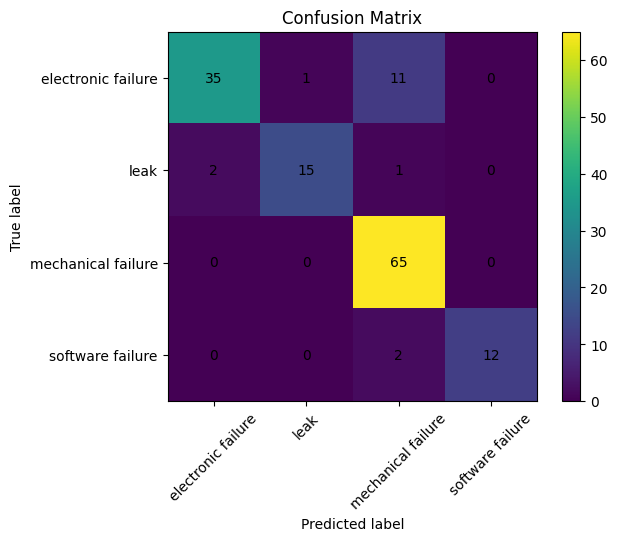

In [40]:
# step 9
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

labels = ['electronic failure', 'leak', 'mechanical failure', 'software failure']

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.colorbar()

plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()

## Report
**Q1) Which techniques would you use for keyword normalization in NLP the process of converting a keyword into its base form?**

Keyword normalization is used to convert words into their base form. Some common techniques are stemming and lemmatization. Stemming removes suffixes from words, while lemmatization converts words into their meaningful root form using vocabulary and grammar. Lemmatization is generally more accurate than stemming.


**Q2) What is TF-IDF in NLP?**

TF-IDF stands for Term Frequency–Inverse Document Frequency. It is a technique used to measure how important a word is in a document compared to the entire dataset. Words that appear frequently in one document but not in others get higher importance. It helps in converting text data into numerical form for machine learning models.


**Q3) What are some alternatives for TF-IDF method to parse text data?**

Some alternatives to TF-IDF are Bag of Words (BoW), Word2Vec, GloVe, and FastText. Bag of Words simply counts word occurrences, while Word2Vec and GloVe create word embeddings that capture relationships between words. FastText improves embeddings by considering subwords.


**Q4) What advantage(s) does word2vec has over TF-IDF?**

Word2Vec captures the semantic meaning and relationships between words, while TF-IDF only focuses on word frequency. For example, Word2Vec can understand that “king” and “queen” are related, but TF-IDF treats them as completely separate. This makes Word2Vec more powerful for understanding context.


**Q5) Provide two applications of the above lab assignment problem.**

One application is automatic fault classification in industries, where machine reports can be categorized into types of failures like mechanical or software issues. Another application is customer support systems, where user complaints can be automatically classified into categories for faster resolution.